# 1.3 Phân Cụm Dữ Liệu
**Các độ đo đánh giá:**
- *Nội tại:* Silhouette, Davies-Bouldin, Calinski-Harabasz
- *Ngoại tại (so với pseudo-label từ đầu ra):* Rand Index, ARI, MI, AMI, NMI
- *So sánh chéo K-Means ↔ GMM:* Rand Index, ARI, MI, AMI, NMI

## 0. Khai báo thư viện và đường dẫn

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    rand_score, adjusted_rand_score,
    mutual_info_score, adjusted_mutual_info_score, normalized_mutual_info_score
)

# ─── Đường dẫn ───────────────────────────────────────────────────────────────
CODE_DIR  = Path.cwd()
ROOT_DIR  = CODE_DIR.parent
DATA_DIR  = ROOT_DIR / "processed_data"
DATA_PATH = DATA_DIR / "encoded_ai_company_adoption.csv"

FIG_BASE = ROOT_DIR / "figure" / "03_clustering"
FIG_KM   = FIG_BASE / "kmeans"
FIG_GMM  = FIG_BASE / "gmm"
FIG_CMP  = FIG_BASE / "comparison"

for d in [FIG_KM, FIG_GMM, FIG_CMP]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_COL = "ai_failure_rate"

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Thư viện đã sẵn sàng.")

Thư viện đã sẵn sàng.


## 1. Đọc & chuẩn bị dữ liệu

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Cột đầu ra: '{TARGET_COL}'")
display(df.head(3))

Shape: (150000, 87)
Cột đầu ra: 'ai_failure_rate'


,survey_year,company_size,num_employees,annual_revenue_usd_millions,company_age,ai_adoption_rate,ai_adoption_stage,years_using_ai,num_ai_tools_used,ai_projects_active,...,ai_primary_tool_Other,ai_use_case_Fraud Detection,ai_use_case_HR Automation,ai_use_case_Marketing Automation,ai_use_case_Medical Diagnostics,ai_use_case_Predictive Maintenance,ai_use_case_Software Development,ai_use_case_Supply Chain Optimization,cost_reduction_percent,customer_satisfaction
0,2023,0,57,48.31,29,30.57,1,3,1,3,...,0,0,0,0,0,0,0,0,9.45,5.20
1,2023,0,57,48.31,29,27.25,1,4,3,0,...,0,0,0,0,0,0,1,0,0.00,6.98
2,2023,0,57,48.31,29,31.54,1,2,3,3,...,0,0,1,0,0,0,0,0,9.74,4.12


In [3]:
# Tách đầu vào / đầu ra
y = df[TARGET_COL].copy()
X = df.drop(columns=[TARGET_COL]).copy()
X = X.fillna(X.median(numeric_only=True))

# Chuẩn hóa Z-score
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Số mẫu: {X_scaled.shape[0]}, Số chiều: {X_scaled.shape[1]}")
print(f"\nThống kê '{TARGET_COL}':")
print(y.describe().round(4))

Số mẫu: 150000, Số chiều: 86

Thống kê 'ai_failure_rate':
count    150000.0000
mean         25.7743
std           7.7610
min           0.0000
25%          20.2700
50%          25.8800
75%          31.5200
max          40.0000
Name: ai_failure_rate, dtype: float64


In [4]:
# Pseudo-label từ đầu ra: chia 3 nhóm quantile → dùng làm ground truth cho độ đo ngoại tại
y_pseudo = pd.qcut(y, q=3, labels=False, duplicates='drop').astype(int)
print("Phân bố pseudo-label (3 nhóm quantile của đầu ra):")
print(y_pseudo.value_counts().sort_index().rename("Số mẫu"))

# PCA 2D để trực quan hóa
pca2   = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
var2   = pca2.explained_variance_ratio_.sum()
print(f"\nPCA 2D giải thích: {var2:.2%} phương sai")

Phân bố pseudo-label (3 nhóm quantile của đầu ra):
ai_failure_rate
0    50007
1    50075
2    49918
Name: Số mẫu, dtype: int64

PCA 2D giải thích: 15.35% phương sai


## 2. Hàm tiện ích

In [5]:
def eval_internal(X, labels, method_name):
    """Độ đo nội tại – không cần nhãn thật."""
    n_clusters = len(set(labels))
    row = {"Phương pháp": method_name, "Số cụm": n_clusters}
    if n_clusters >= 2:
        row["Silhouette"]        = round(silhouette_score(X, labels, sample_size=min(3000, len(X)),random_state=4), 4)
        row["Davies-Bouldin"]    = round(davies_bouldin_score(X, labels), 4)
        row["Calinski-Harabasz"] = round(calinski_harabasz_score(X, labels), 2)
    else:
        row["Silhouette"] = row["Davies-Bouldin"] = row["Calinski-Harabasz"] = np.nan
    return row


def eval_external(labels_pred, labels_true, method_name):
    """Độ đo ngoại tại – so với pseudo ground truth."""
    lp, lt = np.array(labels_pred), np.array(labels_true)
    return {
        "Phương pháp"        : method_name,
        "Rand Index"         : round(rand_score(lt, lp), 4),
        "ARI"                : round(adjusted_rand_score(lt, lp), 4),
        "Mutual Information" : round(mutual_info_score(lt, lp), 4),
        "AMI"                : round(adjusted_mutual_info_score(lt, lp), 4),
        "NMI"                : round(normalized_mutual_info_score(lt, lp), 4),
    }


def eval_crossmethod(label_a, label_b, name_a, name_b):
    """So sánh chéo hai kết quả phân cụm."""
    la, lb = np.array(label_a), np.array(label_b)
    return {
        "Cặp so sánh"        : f"{name_a} vs {name_b}",
        "Rand Index"         : round(rand_score(la, lb), 4),
        "ARI"                : round(adjusted_rand_score(la, lb), 4),
        "Mutual Information" : round(mutual_info_score(la, lb), 4),
        "AMI"                : round(adjusted_mutual_info_score(la, lb), 4),
        "NMI"                : round(normalized_mutual_info_score(la, lb), 4),
    }


def plot_clusters_pca(X_pca, labels, title, ax, var_explained=None):
    unique_labels = sorted(set(labels))
    cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[cmap(i)], label=f"Cụm {lbl}",
                   s=30, alpha=0.75, edgecolors='none')
    subtitle = f"\n(PCA 2D – {var_explained:.1%} phương sai)" if var_explained else ""
    ax.set_title(title + subtitle, fontweight='bold')
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=8, markerscale=1.3)


def plot_output_per_cluster(labels, y_vals, title, ax):
    df_tmp = pd.DataFrame({"label": labels, "y": np.array(y_vals)})
    order  = sorted(df_tmp["label"].unique())
    df_tmp["label"] = df_tmp["label"].astype(str)
    sns.boxplot(data=df_tmp, x="label", y="y",
                order=[str(o) for o in order], ax=ax,
                palette="tab10", flierprops=dict(marker='o', markersize=3))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Cụm"); ax.set_ylabel(TARGET_COL)


def plot_cluster_heatmap(df_feat, labels, method_name, folder, filename):
    """Heatmap Z-score profile từng cụm."""
    df_tmp = df_feat.copy()
    df_tmp["cluster"] = labels
    means   = df_tmp.groupby("cluster")[df_feat.columns].mean()
    means_z = (means - means.mean()) / (means.std() + 1e-9)
    n_cl    = len(means_z)
    fig, ax = plt.subplots(figsize=(min(len(df_feat.columns)*0.45+2, 24), max(n_cl*0.9+1, 4)))
    sns.heatmap(means_z, cmap="RdBu_r", center=0, linewidths=0.3, ax=ax,
                cbar_kws={"label": "Z-score so với trung bình toàn tập"})
    ax.set_title(f"Heatmap profile cụm – {method_name}", fontweight='bold')
    ax.set_xlabel("Feature"); ax.set_ylabel("Cụm")
    plt.tight_layout()
    savefig(fig, folder, filename)
    plt.show()


def cluster_output_stats(labels, y_vals, method_name):
    """Thống kê đầu ra theo từng cụm."""
    df_tmp = pd.DataFrame({"cluster": labels, "y": np.array(y_vals)})
    stats  = df_tmp.groupby("cluster")["y"].agg(
        ["count", "mean", "median", "std", "min", "max"]).round(4)
    stats.columns = ["Số mẫu", "Trung bình", "Trung vị", "Std", "Min", "Max"]
    print(f"Thống kê '{TARGET_COL}' theo cụm – {method_name}:")
    display(stats)
    return stats


def savefig(fig, folder: Path, filename: str):
    path = folder / filename
    fig.savefig(path, bbox_inches='tight')
    print(f"  Saved → {path.relative_to(ROOT_DIR)}")


print("Hàm tiện ích đã định nghĩa.")

Hàm tiện ích đã định nghĩa.


---
## 3. K-Means

### 3.1 Chọn K tối ưu – Elbow, Silhouette, Davies-Bouldin

  Saved → figure\03_clustering\kmeans\01_k_selection.png


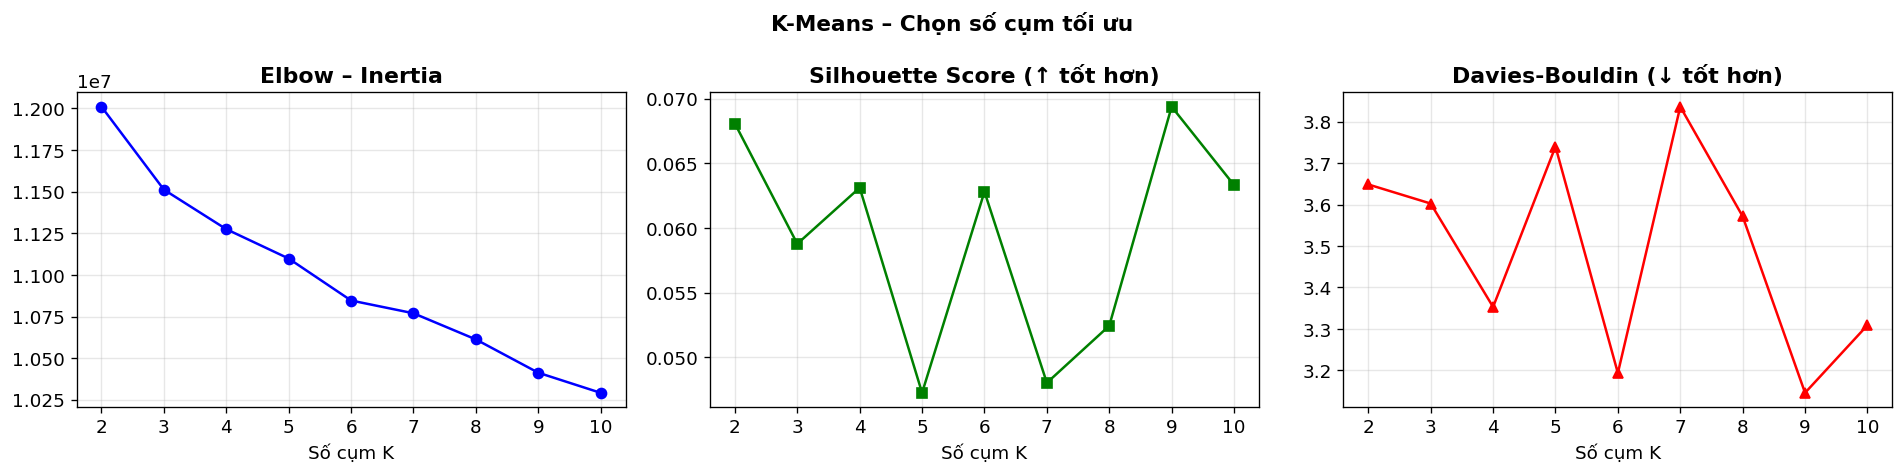

,K,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,12010673.93,0.0681,11106.59,3.6484
1,3,11512375.29,0.0588,9039.82,3.6024
2,4,11274902.19,0.0631,7206.52,3.3530
3,5,11098453.76,0.0473,6086.95,3.7397
4,6,10846390.05,0.0628,5679.85,3.1937
5,7,10769688.34,0.0480,4944.93,3.8359
6,8,10612616.58,0.0524,4618.35,3.5715
7,9,10412561.11,0.0694,4478.89,3.1460
8,10,10291696.32,0.0633,4223.68,3.3090


In [6]:
K_range = range(2, 11)
inertias, sil_km, ch_km, db_km = [], [], [], []

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_km.append(silhouette_score(X_scaled, lbl, sample_size=5000, random_state=42))
    ch_km.append(calinski_harabasz_score(X_scaled, lbl))
    db_km.append(davies_bouldin_score(X_scaled, lbl))

Ks  = list(K_range)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(Ks, inertias, 'bo-'); axes[0].set_title("Elbow – Inertia",             fontweight='bold')
axes[1].plot(Ks, sil_km,   'gs-'); axes[1].set_title("Silhouette Score (↑ tốt hơn)",fontweight='bold')
axes[2].plot(Ks, db_km,    'r^-'); axes[2].set_title("Davies-Bouldin (↓ tốt hơn)", fontweight='bold')
for ax in axes:
    ax.set_xlabel("Số cụm K"); ax.grid(True, alpha=0.3)
plt.suptitle("K-Means – Chọn số cụm tối ưu", fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_KM, "01_k_selection.png")
plt.show()

score_df_km = pd.DataFrame({
    "K": Ks,
    "Inertia"           : [round(v, 2) for v in inertias],
    "Silhouette"        : [round(v, 4) for v in sil_km],
    "Calinski-Harabasz" : [round(v, 2) for v in ch_km],
    "Davies-Bouldin"    : [round(v, 4) for v in db_km],
})
display(score_df_km)

### 3.2 Huấn luyện K-Means với K tối ưu

In [7]:
#K_OPT     = int(score_df_km.loc[score_df_km["Silhouette"].idxmax(), "K"])
K_OPT = 3
print(f"K tối ưu: {K_OPT}")

km_best   = KMeans(n_clusters=K_OPT, random_state=42, n_init=20)
km_labels = km_best.fit_predict(X_scaled)

print("\nPhân bố mẫu theo cụm K-Means:")
print(pd.Series(km_labels).value_counts().sort_index().rename("Số mẫu"))

K tối ưu: 3

Phân bố mẫu theo cụm K-Means:
0    21591
1    66537
2    61872
Name: Số mẫu, dtype: int64


In [8]:
from pathlib import Path

out_path = DATA_DIR / "kmeans_k3_labels.csv"

labels_df = pd.DataFrame({
    "row_index":      range(len(km_labels)),
    "cluster_kmeans": km_labels,
})
labels_df.to_csv(out_path, index=False)
print(f"Da luu nhan cum K-Means K=3 vao: {out_path}")
print(f"So mau: {len(labels_df)} | Phan bo cum:")
print(labels_df["cluster_kmeans"].value_counts().sort_index())


Da luu nhan cum K-Means K=3 vao: f:\Project\Global_AI_Impact\processed_data\kmeans_k3_labels.csv
So mau: 150000 | Phan bo cum:
cluster_kmeans
0    21591
1    66537
2    61872
Name: count, dtype: int64


### 3.3 Trực quan hóa phân cụm K-Means

  Saved → figure\03_clustering\kmeans\02_clusters_pca2d_and_output.png


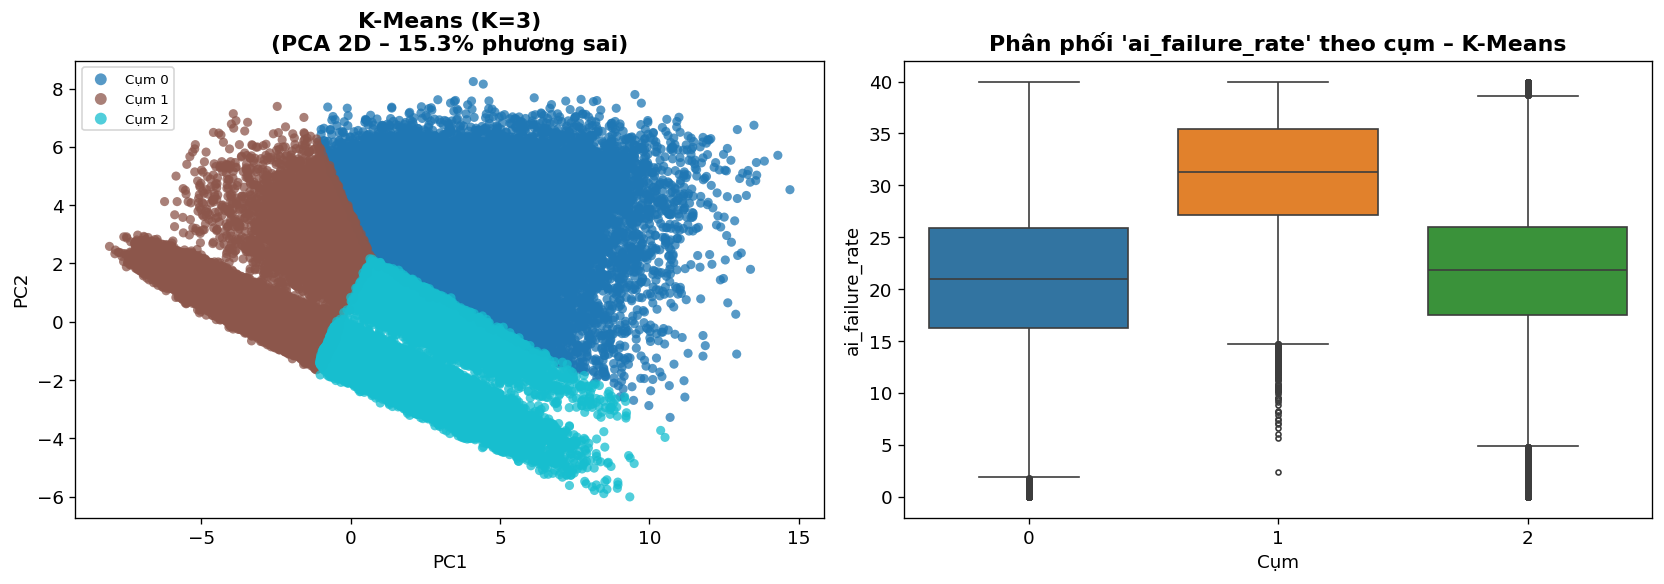

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_clusters_pca(X_pca2, km_labels, f"K-Means (K={K_OPT})", axes[0], var2)
plot_output_per_cluster(km_labels, y, f"Phân phối '{TARGET_COL}' theo cụm – K-Means", axes[1])
plt.tight_layout()
savefig(fig, FIG_KM, "02_clusters_pca2d_and_output.png")
plt.show()

### 3.4 Heatmap profile cụm & thống kê đầu ra – K-Means

  Saved → figure\03_clustering\kmeans\03_cluster_profile_heatmap.png


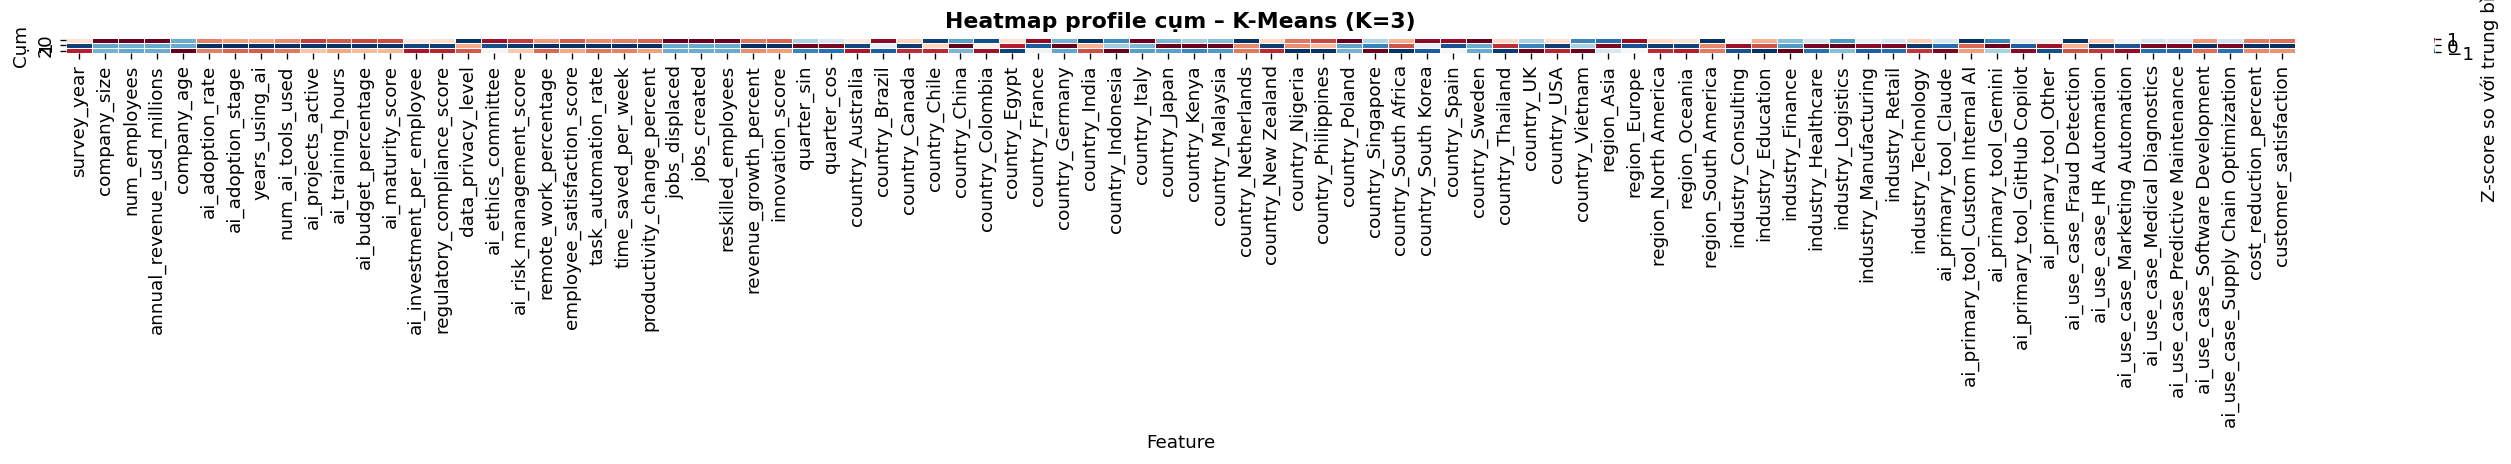

In [10]:
plot_cluster_heatmap(X, km_labels, f"K-Means (K={K_OPT})",
                     FIG_KM, "03_cluster_profile_heatmap.png")

In [11]:
stats_km = cluster_output_stats(km_labels, y, f"K-Means (K={K_OPT})")

Thống kê 'ai_failure_rate' theo cụm – K-Means (K=3):


,Số mẫu,Trung bình,Trung vị,Std,Min,Max
cluster,,,,,,
0,21591,21.0743,20.95,7.1064,0.00,40.0
1,66537,31.0407,31.28,5.7292,2.35,40.0
2,61872,21.7511,21.82,6.2758,0.00,40.0


### 3.5 Đánh giá độ đo – K-Means

In [12]:
km_internal = eval_internal(X_scaled, km_labels, f"K-Means (K={K_OPT})")
km_external = eval_external(km_labels, y_pseudo,  f"K-Means (K={K_OPT})")

print("── Độ đo nội tại ──")
display(pd.DataFrame([km_internal]))
print("\n── Độ đo ngoại tại (so với pseudo-label 3 nhóm từ đầu ra) ──")
display(pd.DataFrame([km_external]))

── Độ đo nội tại ──


,Phương pháp,Số cụm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means (K=3),3,0.0589,3.6025,9039.82



── Độ đo ngoại tại (so với pseudo-label 3 nhóm từ đầu ra) ──


,Phương pháp,Rand Index,ARI,Mutual Information,AMI,NMI
0,K-Means (K=3),0.6301,0.2003,0.1955,0.1858,0.1858


---
## 4. GMM – Gaussian Mixture Model
### 4.1 Chọn số thành phần K tối ưu – BIC, AIC, Silhouette

  Saved → figure\03_clustering\gmm\01_component_selection.png


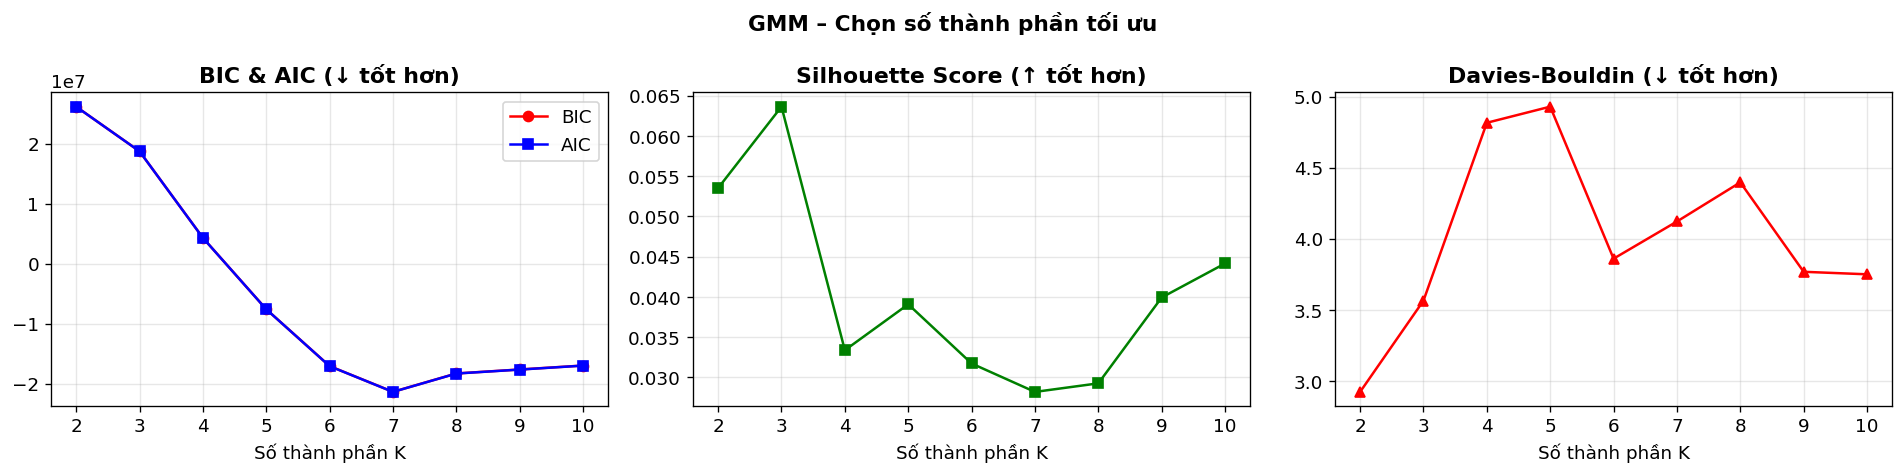

,K,BIC,AIC,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,26141526.90,26138105.06,0.0535,3802.95,2.9232
1,3,18709305.38,18704167.66,0.0637,5532.77,3.5653
2,4,4290651.75,4283798.15,0.0334,4888.94,4.8169
3,5,-7611140.03,-7619709.52,0.0391,3677.53,4.9303
4,6,-17085883.84,-17096169.21,0.0317,3393.60,3.8607
5,7,-21373472.73,-21385473.98,0.0282,3121.32,4.1223
6,8,-18311986.87,-18325704.00,0.0293,2668.82,4.3977
7,9,-17650111.72,-17665544.73,0.0399,2962.74,3.7683
8,10,-16989057.27,-17006206.16,0.0442,2625.55,3.7507


In [13]:
n_range = range(2, 11)
bics, aics, sil_gmm, ch_gmm, db_gmm = [], [], [], [], []

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='diag',
                          random_state=42, max_iter=100, n_init=1)
    gmm.fit(X_scaled)
    lbl = gmm.predict(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))
    sil_gmm.append(silhouette_score(X_scaled, lbl, sample_size=5000, random_state=42))
    ch_gmm.append(calinski_harabasz_score(X_scaled, lbl))
    db_gmm.append(davies_bouldin_score(X_scaled, lbl))

Ns  = list(n_range)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(Ns, bics,    'ro-', label='BIC')
axes[0].plot(Ns, aics,    'bs-', label='AIC')
axes[0].set_title("BIC & AIC (↓ tốt hơn)",           fontweight='bold'); axes[0].legend()
axes[1].plot(Ns, sil_gmm, 'gs-'); axes[1].set_title("Silhouette Score (↑ tốt hơn)", fontweight='bold')
axes[2].plot(Ns, db_gmm,  'r^-'); axes[2].set_title("Davies-Bouldin (↓ tốt hơn)",  fontweight='bold')
for ax in axes:
    ax.set_xlabel("Số thành phần K"); ax.grid(True, alpha=0.3)
plt.suptitle("GMM – Chọn số thành phần tối ưu", fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_GMM, "01_component_selection.png")
plt.show()

score_df_gmm = pd.DataFrame({
    "K": Ns,
    "BIC"               : [round(v, 2) for v in bics],
    "AIC"               : [round(v, 2) for v in aics],
    "Silhouette"        : [round(v, 4) for v in sil_gmm],
    "Calinski-Harabasz" : [round(v, 2) for v in ch_gmm],
    "Davies-Bouldin"    : [round(v, 4) for v in db_gmm],
})
display(score_df_gmm)

#N_OPT = Ns[np.argmin(bics)]

### 4.2 Huấn luyện GMM với K tối ưu

In [14]:
N_OPT = 3
print(f"\nK tối ưu: {N_OPT}")
gmm_best   = GaussianMixture(n_components=N_OPT, covariance_type='diag',
                              random_state=42, max_iter=300, n_init=5)
gmm_best.fit(X_scaled)
gmm_labels = gmm_best.predict(X_scaled)

# Xác suất thuộc từng cụm (soft assignment)
gmm_proba  = gmm_best.predict_proba(X_scaled)

print("Phân bố mẫu theo cụm GMM:")
print(pd.Series(gmm_labels).value_counts().sort_index().rename("Số mẫu"))

# Thống kê độ chắc chắn (max probability) – đặc trưng riêng của GMM
max_proba = gmm_proba.max(axis=1)
print(f"\nĐộ chắc chắn phân cụm (max probability):")
print(pd.Series(max_proba).describe().round(4))


K tối ưu: 3
Phân bố mẫu theo cụm GMM:
0    88169
1    20996
2    40835
Name: Số mẫu, dtype: int64

Độ chắc chắn phân cụm (max probability):
count    150000.0000
mean          1.0000
std           0.0002
min           0.9232
25%           1.0000
50%           1.0000
75%           1.0000
max           1.0000
dtype: float64


### 4.3 Trực quan hóa phân cụm GMM

  Saved → figure\03_clustering\gmm\02_clusters_pca2d_and_output.png


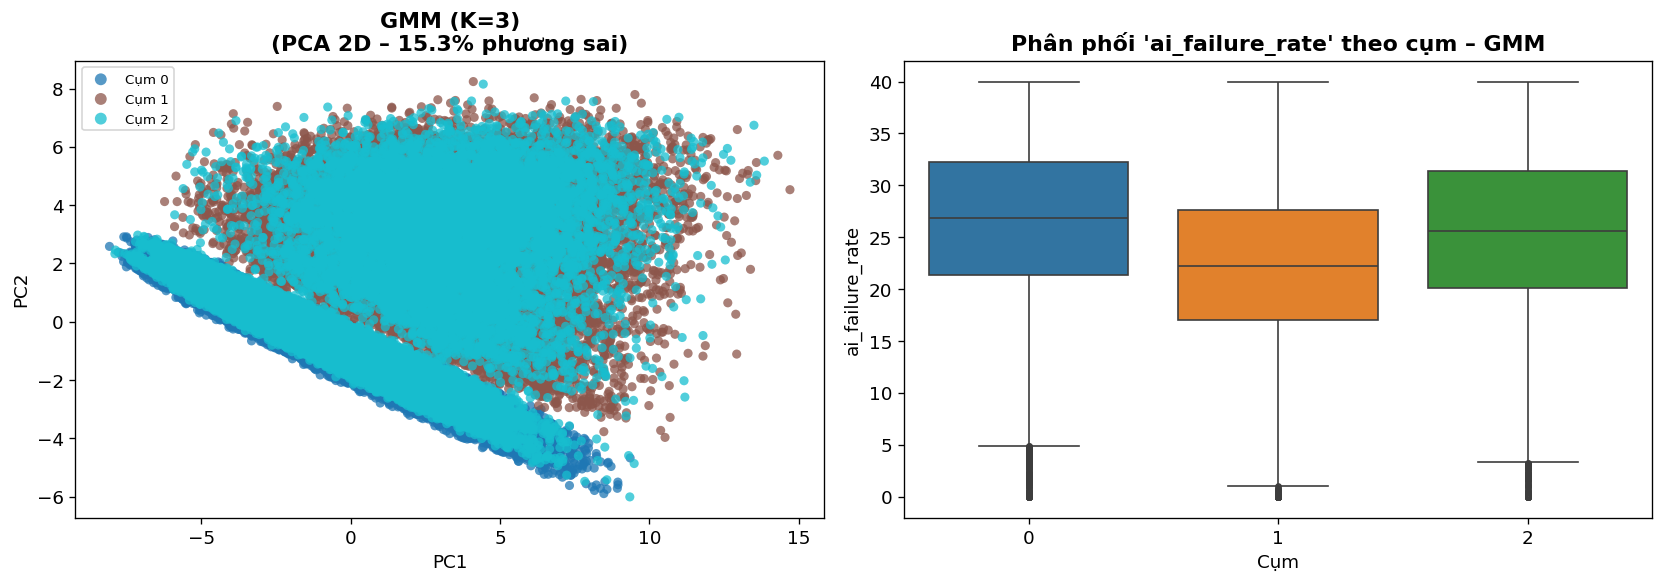

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_clusters_pca(X_pca2, gmm_labels, f"GMM (K={N_OPT})", axes[0], var2)
plot_output_per_cluster(gmm_labels, y, f"Phân phối '{TARGET_COL}' theo cụm – GMM", axes[1])
plt.tight_layout()
savefig(fig, FIG_GMM, "02_clusters_pca2d_and_output.png")
plt.show()

### 4.4 Trực quan hóa độ chắc chắn phân cụm (soft assignment – đặc trưng của GMM)

  Saved → figure\03_clustering\gmm\03_soft_assignment_confidence.png


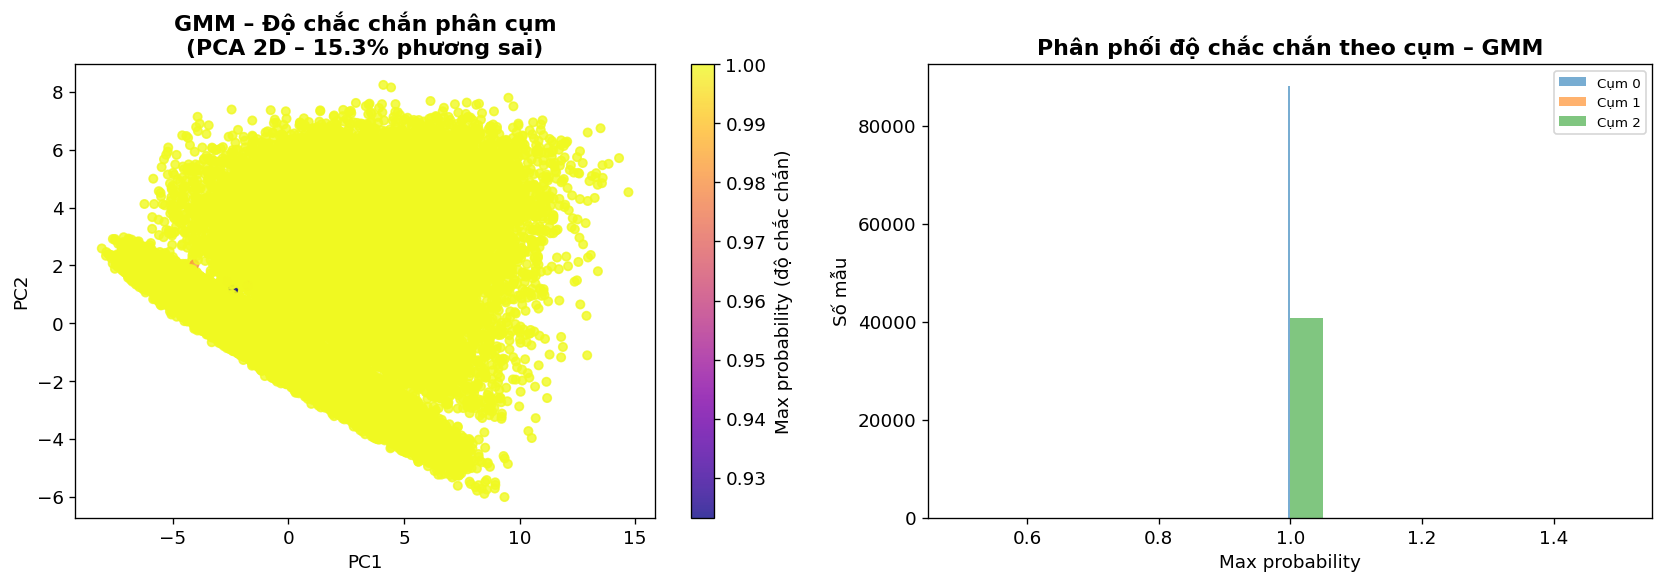

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter tô màu theo max probability
sc = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                     c=max_proba, cmap='plasma', s=25, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='Max probability (độ chắc chắn)')
axes[0].set_title(f"GMM – Độ chắc chắn phân cụm\n(PCA 2D – {var2:.1%} phương sai)",
                  fontweight='bold')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

# Histogram phân phối max probability theo từng cụm
for k in sorted(set(gmm_labels)):
    axes[1].hist(max_proba[gmm_labels == k], bins=20, alpha=0.6, label=f"Cụm {k}")
axes[1].set_title("Phân phối độ chắc chắn theo cụm – GMM", fontweight='bold')
axes[1].set_xlabel("Max probability"); axes[1].set_ylabel("Số mẫu")
axes[1].legend(fontsize=8)

plt.tight_layout()
savefig(fig, FIG_GMM, "03_soft_assignment_confidence.png")
plt.show()

### 4.5 Heatmap profile cụm & thống kê đầu ra – GMM

  Saved → figure\03_clustering\gmm\04_cluster_profile_heatmap.png


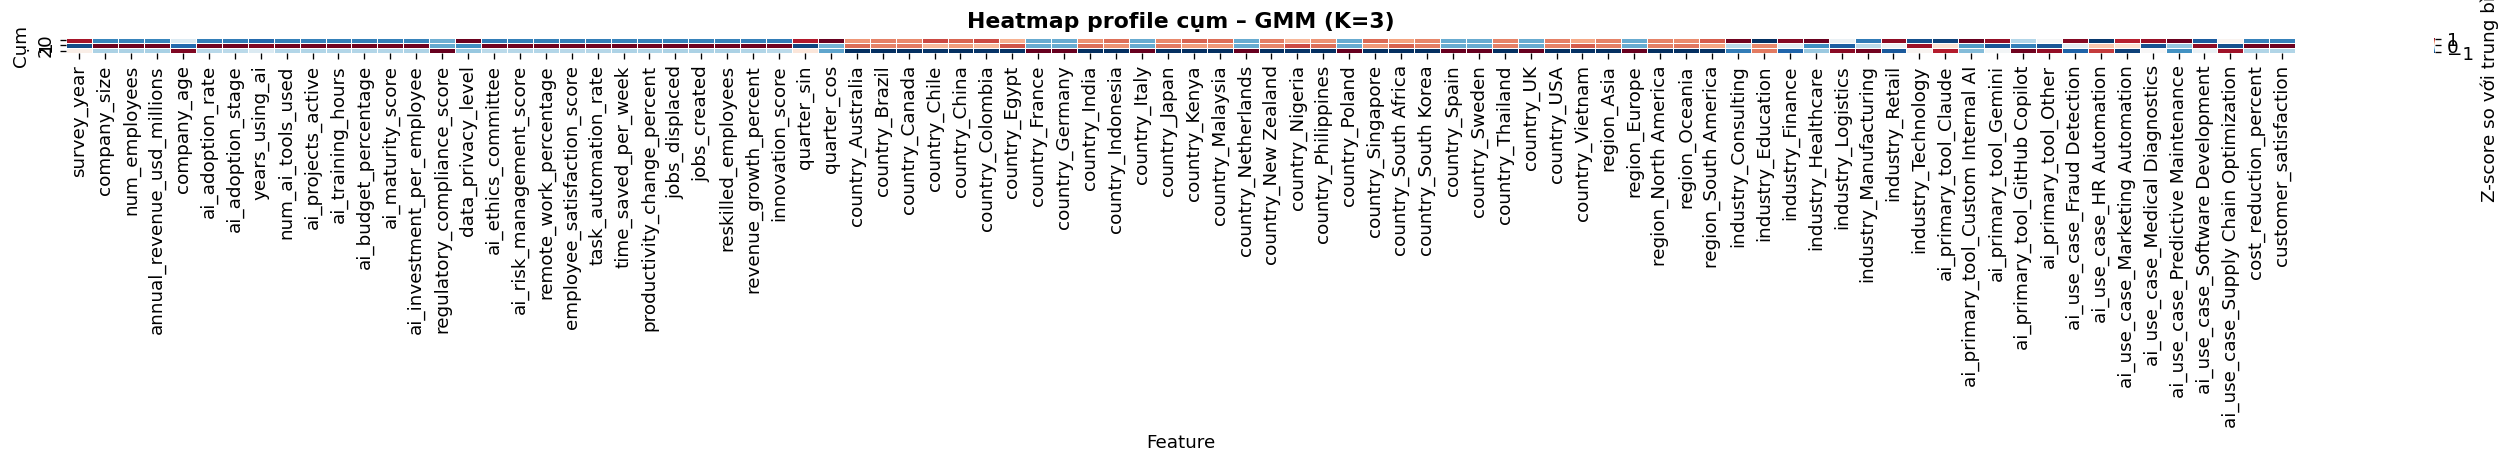

In [17]:
plot_cluster_heatmap(X, gmm_labels, f"GMM (K={N_OPT})",
                     FIG_GMM, "04_cluster_profile_heatmap.png")

In [18]:
stats_gmm = cluster_output_stats(gmm_labels, y, f"GMM (K={N_OPT})")

Thống kê 'ai_failure_rate' theo cụm – GMM (K=3):


,Số mẫu,Trung bình,Trung vị,Std,Min,Max
cluster,,,,,,
0,88169,26.6441,26.850,7.5554,0.0,40.0
1,20996,22.4136,22.235,7.6522,0.0,40.0
2,40835,25.6244,25.650,7.7740,0.0,40.0


### 4.6 Đánh giá độ đo – GMM

In [19]:
gmm_internal = eval_internal(X_scaled, gmm_labels, f"GMM (K={N_OPT})")
gmm_external = eval_external(gmm_labels, y_pseudo,  f"GMM (K={N_OPT})")

print("── Độ đo nội tại ──")
display(pd.DataFrame([gmm_internal]))
print("\n── Độ đo ngoại tại (so với pseudo-label 3 nhóm từ đầu ra) ──")
display(pd.DataFrame([gmm_external]))

── Độ đo nội tại ──


,Phương pháp,Số cụm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,GMM (K=3),3,0.0386,4.3287,5397.8



── Độ đo ngoại tại (so với pseudo-label 3 nhóm từ đầu ra) ──


,Phương pháp,Rand Index,ARI,Mutual Information,AMI,NMI
0,GMM (K=3),0.5247,0.0093,0.0141,0.0138,0.0139


---
## 5. So sánh tổng hợp K-Means và GMM

### 5.1 Trực quan 2 phương pháp song song

  Saved → figure\03_clustering\comparison\01_pca2d_side_by_side.png


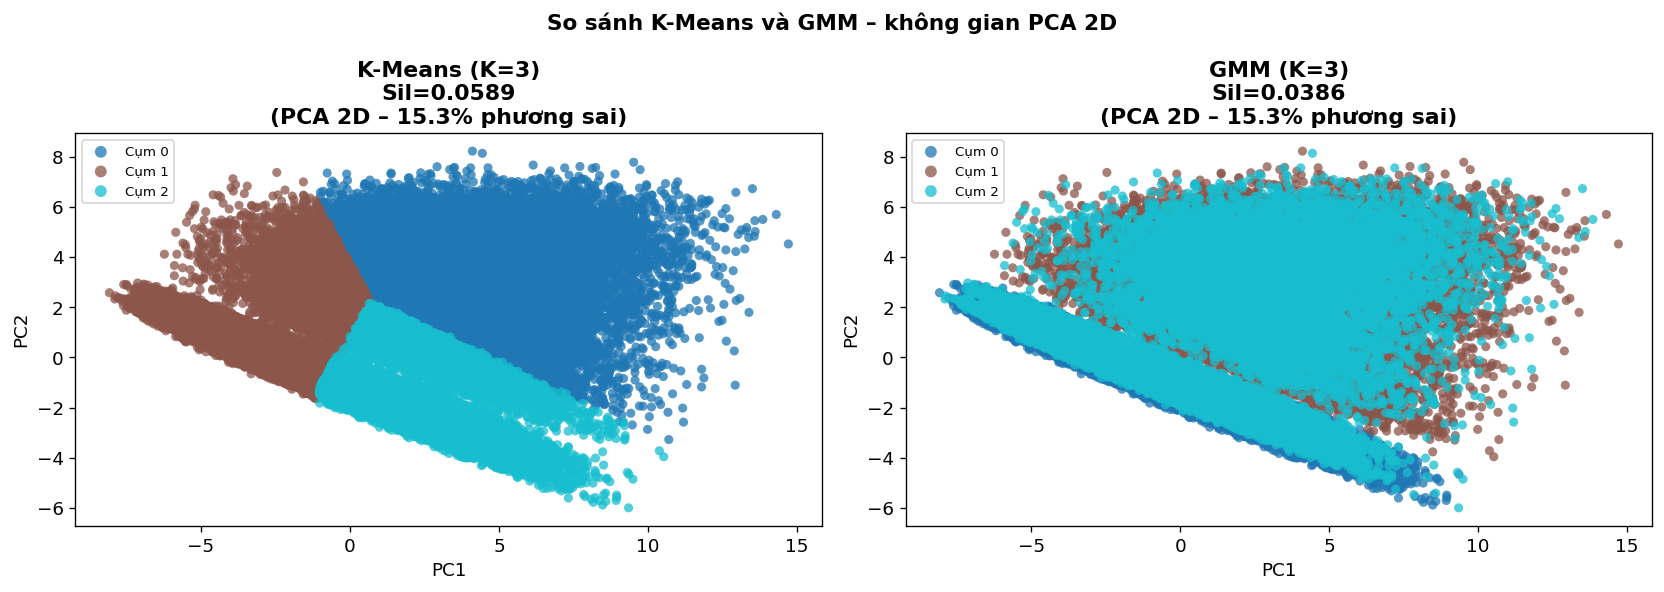

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_clusters_pca(X_pca2, km_labels,
                  f"K-Means (K={K_OPT})\nSil={km_internal['Silhouette']:.4f}",
                  axes[0], var2)
plot_clusters_pca(X_pca2, gmm_labels,
                  f"GMM (K={N_OPT})\nSil={gmm_internal['Silhouette']:.4f}",
                  axes[1], var2)
plt.suptitle("So sánh K-Means và GMM – không gian PCA 2D",
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_CMP, "01_pca2d_side_by_side.png")
plt.show()

  Saved → figure\03_clustering\comparison\02_output_distribution_side_by_side.png


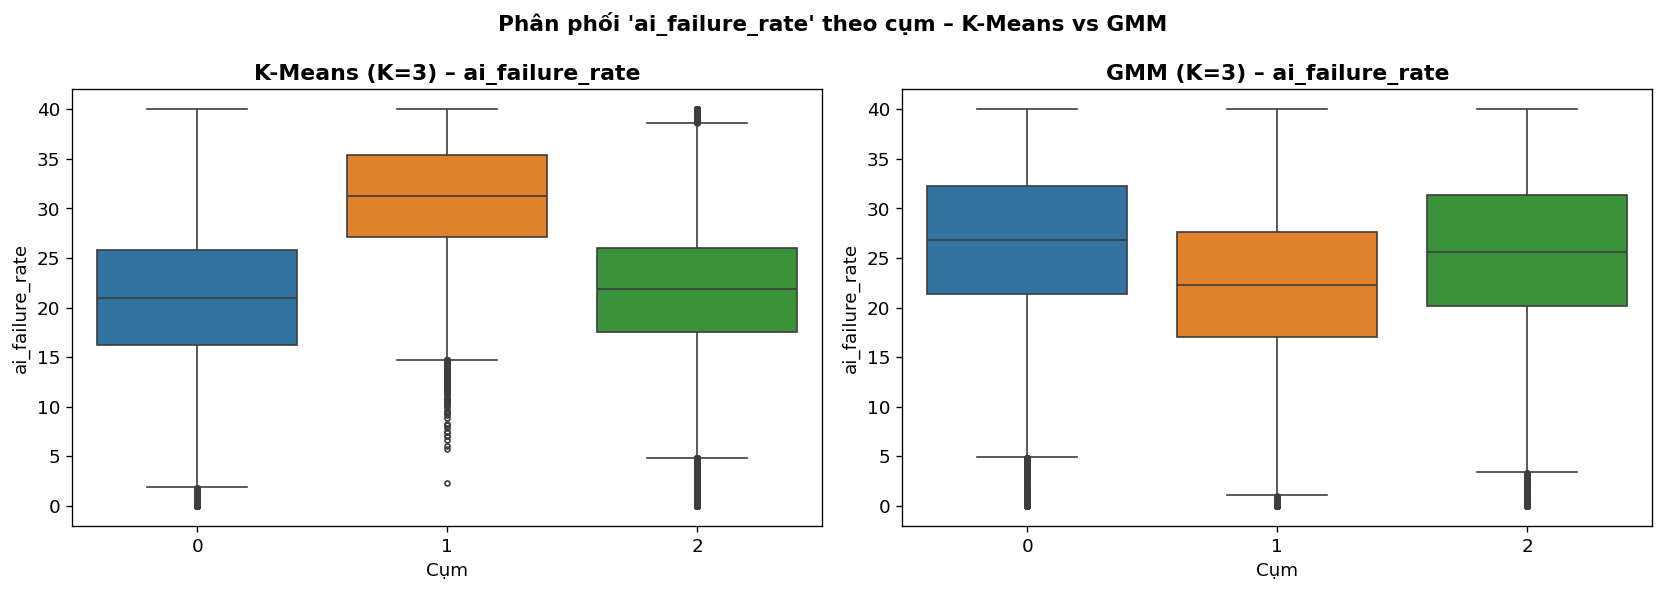

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_output_per_cluster(km_labels,  y, f"K-Means (K={K_OPT}) – {TARGET_COL}",  axes[0])
plot_output_per_cluster(gmm_labels, y, f"GMM (K={N_OPT}) – {TARGET_COL}",      axes[1])
plt.suptitle(f"Phân phối '{TARGET_COL}' theo cụm – K-Means vs GMM",
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_CMP, "02_output_distribution_side_by_side.png")
plt.show()

### 5.2 Bảng tổng hợp độ đo nội tại

In [22]:
internal_df = pd.DataFrame([km_internal, gmm_internal]).set_index("Phương pháp")
print("BẢNG ĐỘ ĐO NỘI TẠI")
print("  Silhouette        : ↑ tốt hơn (max = 1)")
print("  Davies-Bouldin    : ↓ tốt hơn (min = 0)")
print("  Calinski-Harabasz : ↑ tốt hơn")
display(internal_df)

BẢNG ĐỘ ĐO NỘI TẠI
  Silhouette        : ↑ tốt hơn (max = 1)
  Davies-Bouldin    : ↓ tốt hơn (min = 0)
  Calinski-Harabasz : ↑ tốt hơn


,Số cụm,Silhouette,Davies-Bouldin,Calinski-Harabasz
Phương pháp,,,,
K-Means (K=3),3,0.0589,3.6025,9039.82
GMM (K=3),3,0.0386,4.3287,5397.80


### 5.3 Bảng tổng hợp độ đo ngoại tại

In [23]:
external_df = pd.DataFrame([km_external, gmm_external]).set_index("Phương pháp")
print("BẢNG ĐỘ ĐO NGOẠI TẠI  (pseudo ground truth = quantile-bin 3 nhóm của ai_failure_rate)")
print("  Rand Index : tỷ lệ cặp điểm phân loại đúng (max 1)")
print("  ARI        : Rand Index hiệu chỉnh theo cơ hội ngẫu nhiên (0 = ngẫu nhiên, max 1)")
print("  MI         : lượng thông tin chung giữa phân cụm và nhãn tham chiếu")
print("  AMI        : MI hiệu chỉnh theo cơ hội ngẫu nhiên (max 1)")
print("  NMI        : MI chuẩn hóa về [0, 1]")
display(external_df)

BẢNG ĐỘ ĐO NGOẠI TẠI  (pseudo ground truth = quantile-bin 3 nhóm của ai_failure_rate)
  Rand Index : tỷ lệ cặp điểm phân loại đúng (max 1)
  ARI        : Rand Index hiệu chỉnh theo cơ hội ngẫu nhiên (0 = ngẫu nhiên, max 1)
  MI         : lượng thông tin chung giữa phân cụm và nhãn tham chiếu
  AMI        : MI hiệu chỉnh theo cơ hội ngẫu nhiên (max 1)
  NMI        : MI chuẩn hóa về [0, 1]


,Rand Index,ARI,Mutual Information,AMI,NMI
Phương pháp,,,,,
K-Means (K=3),0.6301,0.2003,0.1955,0.1858,0.1858
GMM (K=3),0.5247,0.0093,0.0141,0.0138,0.0139


### 5.4 So sánh chéo K-Means ↔ GMM

In [24]:
cross = eval_crossmethod(km_labels, gmm_labels, f"K-Means (K={K_OPT})", f"GMM (K={N_OPT})")
cross_df = pd.DataFrame([cross]).set_index("Cặp so sánh")
print("SO SÁNH CHÉO K-Means ↔ GMM  (không cần ground truth)")
print("  ARI/AMI/NMI gần 1 → hai phương pháp cho kết quả phân cụm tương đồng")
display(cross_df)

SO SÁNH CHÉO K-Means ↔ GMM  (không cần ground truth)
  ARI/AMI/NMI gần 1 → hai phương pháp cho kết quả phân cụm tương đồng


,Rand Index,ARI,Mutual Information,AMI,NMI
Cặp so sánh,,,,,
K-Means (K=3) vs GMM (K=3),0.5983,0.1741,0.2137,0.2195,0.2195


### 5.5 Heatmap tổng hợp độ đo

  Saved → figure\03_clustering\comparison\03_metrics_heatmap.png


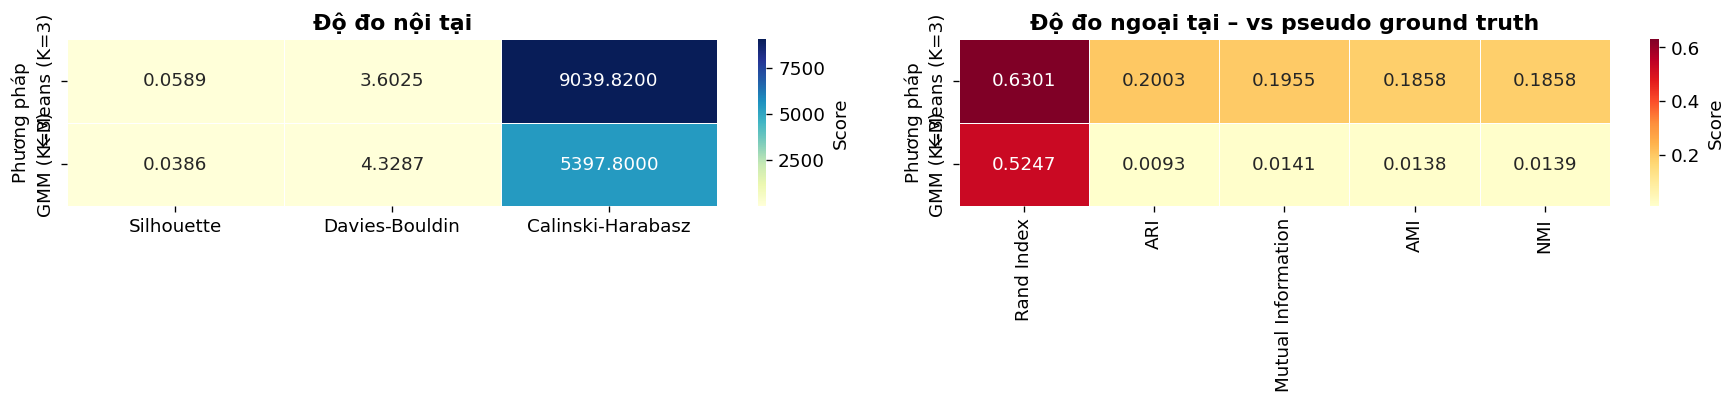

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3.5))

# Nội tại
internal_plot = internal_df[["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]].astype(float)
sns.heatmap(internal_plot, annot=True, fmt=".4f", cmap="YlGnBu",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Score"})
axes[0].set_title("Độ đo nội tại", fontweight='bold')

# Ngoại tại
sns.heatmap(external_df.astype(float), annot=True, fmt=".4f", cmap="YlOrRd",
            ax=axes[1], linewidths=0.5, cbar_kws={"label": "Score"})
axes[1].set_title("Độ đo ngoại tại – vs pseudo ground truth", fontweight='bold')

plt.tight_layout()
savefig(fig, FIG_CMP, "03_metrics_heatmap.png")
plt.show()

## 6. Lưu nhãn cụm & liệt kê ảnh đã xuất

In [26]:
df_out = df.copy()
df_out["cluster_kmeans"] = km_labels
df_out["cluster_gmm"]    = gmm_labels

out_path = DATA_DIR / "encoded_ai_company_with_clusters.csv"
df_out.to_csv(out_path, index=False)
print(f"Đã lưu dữ liệu có nhãn cụm.")

print("\nDanh sách ảnh đã xuất:")
for p in sorted(FIG_BASE.rglob("*.png")):
    print(f"  {p.relative_to(ROOT_DIR)}")

Đã lưu dữ liệu có nhãn cụm.

Danh sách ảnh đã xuất:
  figure\03_clustering\comparison\01_pca2d_side_by_side.png
  figure\03_clustering\comparison\02_output_distribution_side_by_side.png
  figure\03_clustering\comparison\03_metrics_heatmap.png
  figure\03_clustering\gmm\01_component_selection.png
  figure\03_clustering\gmm\02_clusters_pca2d_and_output.png
  figure\03_clustering\gmm\03_soft_assignment_confidence.png
  figure\03_clustering\gmm\04_cluster_profile_heatmap.png
  figure\03_clustering\kmeans\01_k_selection.png
  figure\03_clustering\kmeans\02_clusters_pca2d_and_output.png
  figure\03_clustering\kmeans\03_cluster_profile_heatmap.png


---
## 8. Phân Cụm Trên Dữ Liệu Giảm Chiều (PCA & TruncatedSVD)


### 8.0 Thư viện bổ sung & cấu hình đường dẫn


In [27]:
from sklearn.decomposition import PCA, TruncatedSVD

FIG_DR = FIG_BASE / "dim_reduced"
FIG_DR_KM  = FIG_DR / "kmeans"
FIG_DR_GMM = FIG_DR / "gmm"
FIG_DR_CMP = FIG_DR / "comparison"
for d in [FIG_DR_KM, FIG_DR_GMM, FIG_DR_CMP]:
    d.mkdir(parents=True, exist_ok=True)

print("Thư viện giảm chiều đã sẵn sàng.")


Thư viện giảm chiều đã sẵn sàng.


### 8.1 Chuẩn bị dữ liệu giảm chiều


In [28]:
# ─── Xác định số thành phần để đạt ≥80% phương sai ───────────────────────────
VARIANCE_THRESHOLD = 0.80

# PCA full để tìm n_components
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var_pca = np.cumsum(pca_full.explained_variance_ratio_)
n_pca = int(np.searchsorted(cum_var_pca, VARIANCE_THRESHOLD) + 1)
print(f"PCA: cần {n_pca} thành phần để đạt {cum_var_pca[n_pca-1]:.2%} phương sai tích lũy")

# TruncatedSVD full để tìm n_components
max_svd = min(X_scaled.shape[0] - 1, X_scaled.shape[1])
svd_full = TruncatedSVD(n_components=max_svd, random_state=42)
svd_full.fit(X_scaled)
cum_var_svd = np.cumsum(svd_full.explained_variance_ratio_)
n_svd = int(np.searchsorted(cum_var_svd, VARIANCE_THRESHOLD) + 1)
print(f"TruncatedSVD: cần {n_svd} thành phần để đạt {cum_var_svd[n_svd-1]:.2%} phương sai tích lũy")

print(f"\nSố chiều gốc: {X_scaled.shape[1]}")
print(f"PCA  → {n_pca} chiều  (giảm {(1 - n_pca/X_scaled.shape[1]):.1%})")
print(f"SVD  → {n_svd} chiều  (giảm {(1 - n_svd/X_scaled.shape[1]):.1%})")


PCA: cần 47 thành phần để đạt 80.99% phương sai tích lũy
TruncatedSVD: cần 47 thành phần để đạt 80.99% phương sai tích lũy

Số chiều gốc: 86
PCA  → 47 chiều  (giảm 45.3%)
SVD  → 47 chiều  (giảm 45.3%)


X sau PCA  : (150000, 47)
X sau SVD  : (150000, 47)
  Saved → figure\03_clustering\dim_reduced\scree_plot.png


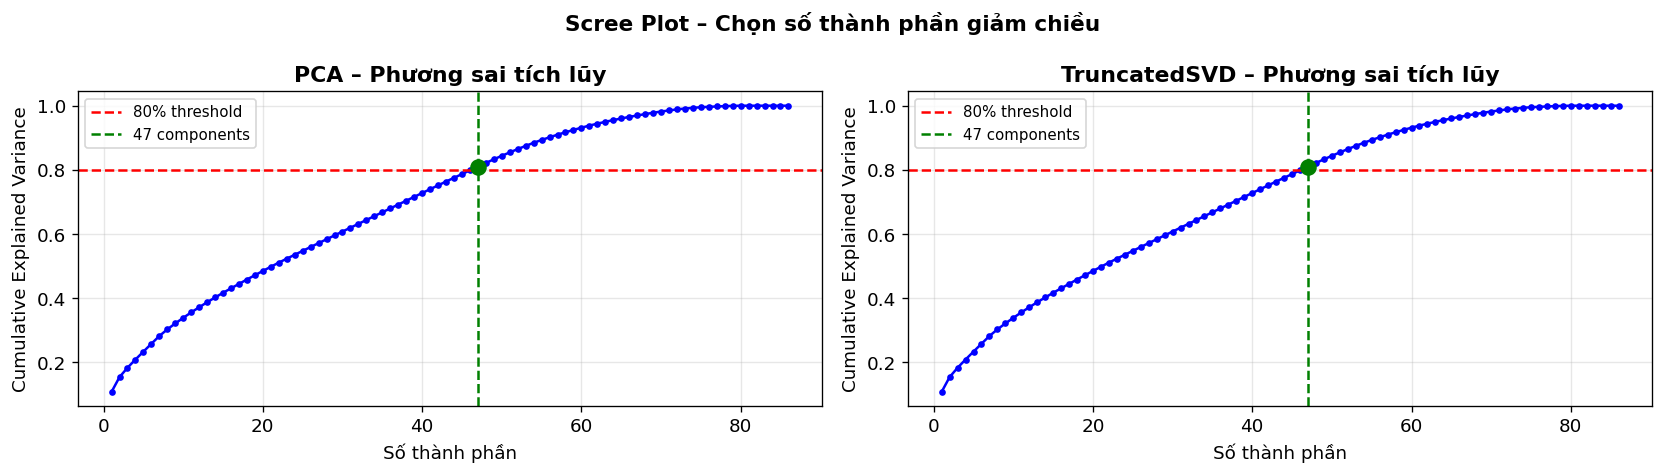

In [29]:
# ─── Giảm chiều thực sự ───────────────────────────────────────────────────────
pca_dr = PCA(n_components=n_pca, random_state=42)
X_pca_dr = pca_dr.fit_transform(X_scaled)

svd_dr = TruncatedSVD(n_components=n_svd, random_state=42)
X_svd_dr = svd_dr.fit_transform(X_scaled)

print(f"X sau PCA  : {X_pca_dr.shape}")
print(f"X sau SVD  : {X_svd_dr.shape}")

# Scree plot cho cả hai
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, cum_var, n_keep, method in [
    (axes[0], cum_var_pca, n_pca, "PCA"),
    (axes[1], cum_var_svd, n_svd, "TruncatedSVD")
]:
    ax.plot(range(1, len(cum_var)+1), cum_var, 'b-o', markersize=3)
    ax.axhline(VARIANCE_THRESHOLD, color='r', linestyle='--', label=f'{VARIANCE_THRESHOLD:.0%} threshold')
    ax.axvline(n_keep, color='g', linestyle='--', label=f'{n_keep} components')
    ax.scatter([n_keep], [cum_var[n_keep-1]], color='green', zorder=5, s=80)
    ax.set_title(f'{method} – Phương sai tích lũy', fontweight='bold')
    ax.set_xlabel('Số thành phần'); ax.set_ylabel('Cumulative Explained Variance')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('Scree Plot – Chọn số thành phần giảm chiều', fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_DR, 'scree_plot.png')
plt.show()


### 8.2 K-Means trên dữ liệu giảm chiều

Dùng cùng K tối ưu đã chọn ở mục 3 (`K_OPT`) để so sánh công bằng với kết quả trên dữ liệu gốc.


In [30]:
# ── K-Means trên PCA ──
km_pca = KMeans(n_clusters=K_OPT, random_state=42, n_init=20)
km_pca_labels = km_pca.fit_predict(X_pca_dr)

# ── K-Means trên SVD ──
km_svd = KMeans(n_clusters=K_OPT, random_state=42, n_init=20)
km_svd_labels = km_svd.fit_predict(X_svd_dr)

print(f"K-Means (K={K_OPT}) trên PCA – phân bố cụm:")
print(pd.Series(km_pca_labels).value_counts().sort_index().rename("Số mẫu"))
print(f"\nK-Means (K={K_OPT}) trên SVD – phân bố cụm:")
print(pd.Series(km_svd_labels).value_counts().sort_index().rename("Số mẫu"))


K-Means (K=3) trên PCA – phân bố cụm:
0    21654
1    66422
2    61924
Name: Số mẫu, dtype: int64

K-Means (K=3) trên SVD – phân bố cụm:
0    21659
1    61876
2    66465
Name: Số mẫu, dtype: int64


  Saved → figure\03_clustering\dim_reduced\kmeans\01_kmeans_3way_comparison.png


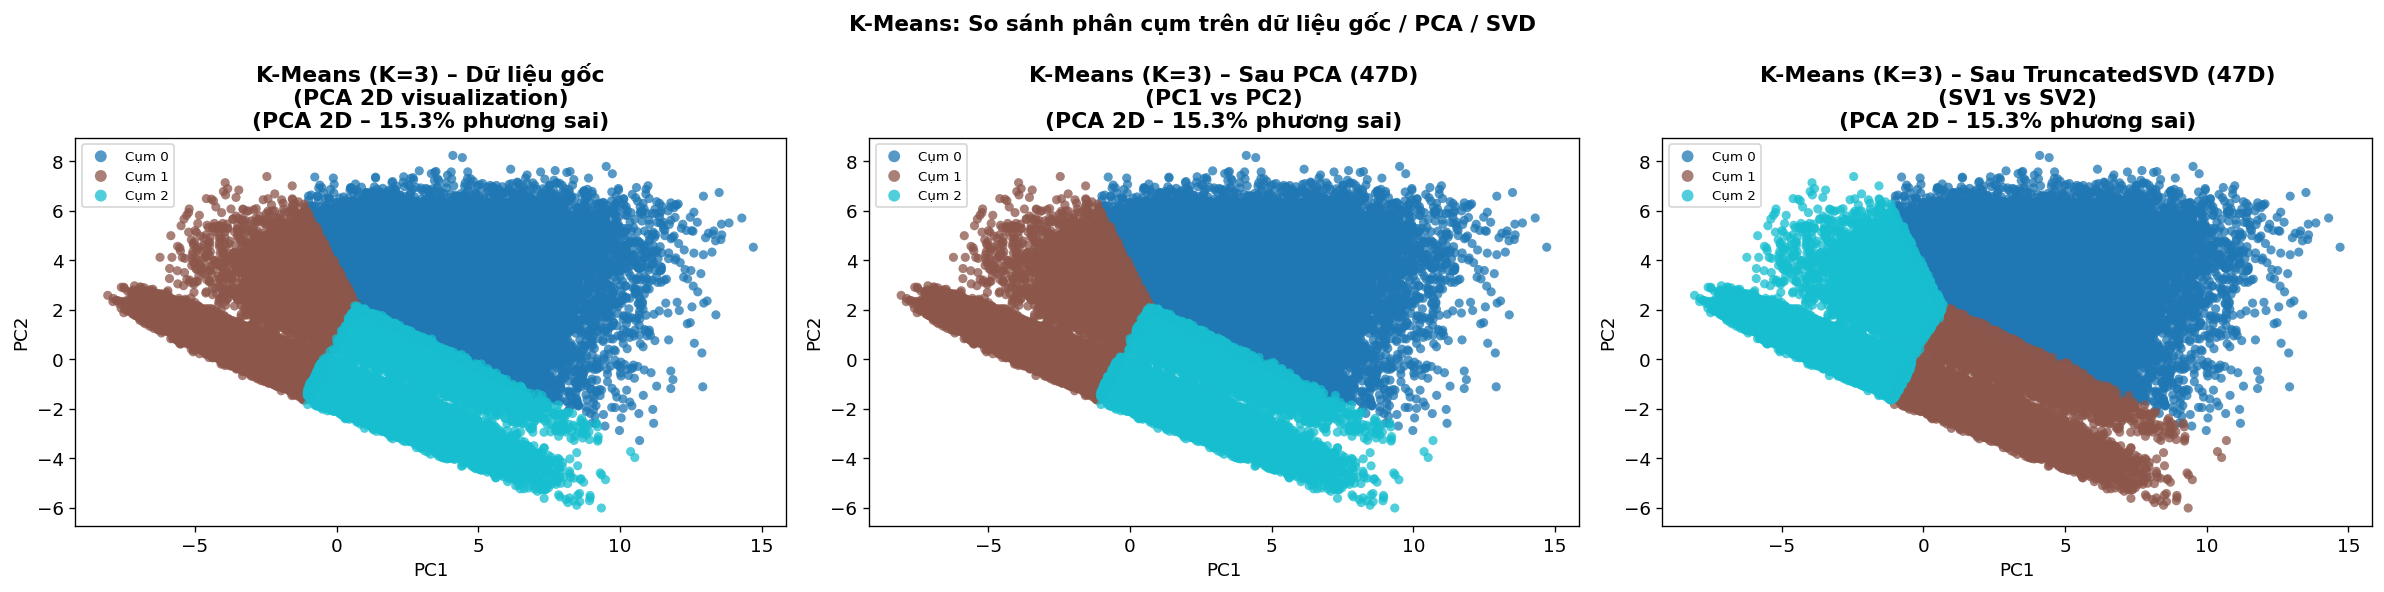

In [31]:
# ── Trực quan hóa K-Means trên dữ liệu giảm chiều ──
# Dùng 2 thành phần đầu của mỗi không gian giảm chiều để vẽ
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gốc (để so sánh)
plot_clusters_pca(X_pca2, km_labels,
                  f"K-Means (K={K_OPT}) – Dữ liệu gốc\n(PCA 2D visualization)",
                  axes[0], var2)

# Sau PCA
var_pca_2d = pca_dr.explained_variance_ratio_[:2].sum() if n_pca >= 2 else pca_dr.explained_variance_ratio_.sum()
plot_clusters_pca(X_pca_dr[:, :2], km_pca_labels,
                  f"K-Means (K={K_OPT}) – Sau PCA ({n_pca}D)\n(PC1 vs PC2)",
                  axes[1], var_pca_2d)

# Sau SVD
var_svd_2d = svd_dr.explained_variance_ratio_[:2].sum() if n_svd >= 2 else svd_dr.explained_variance_ratio_.sum()
plot_clusters_pca(X_svd_dr[:, :2], km_svd_labels,
                  f"K-Means (K={K_OPT}) – Sau TruncatedSVD ({n_svd}D)\n(SV1 vs SV2)",
                  axes[2], var_svd_2d)

plt.suptitle('K-Means: So sánh phân cụm trên dữ liệu gốc / PCA / SVD',
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_DR_KM, '01_kmeans_3way_comparison.png')
plt.show()


  Saved → figure\03_clustering\dim_reduced\kmeans\02_output_boxplot_3way.png


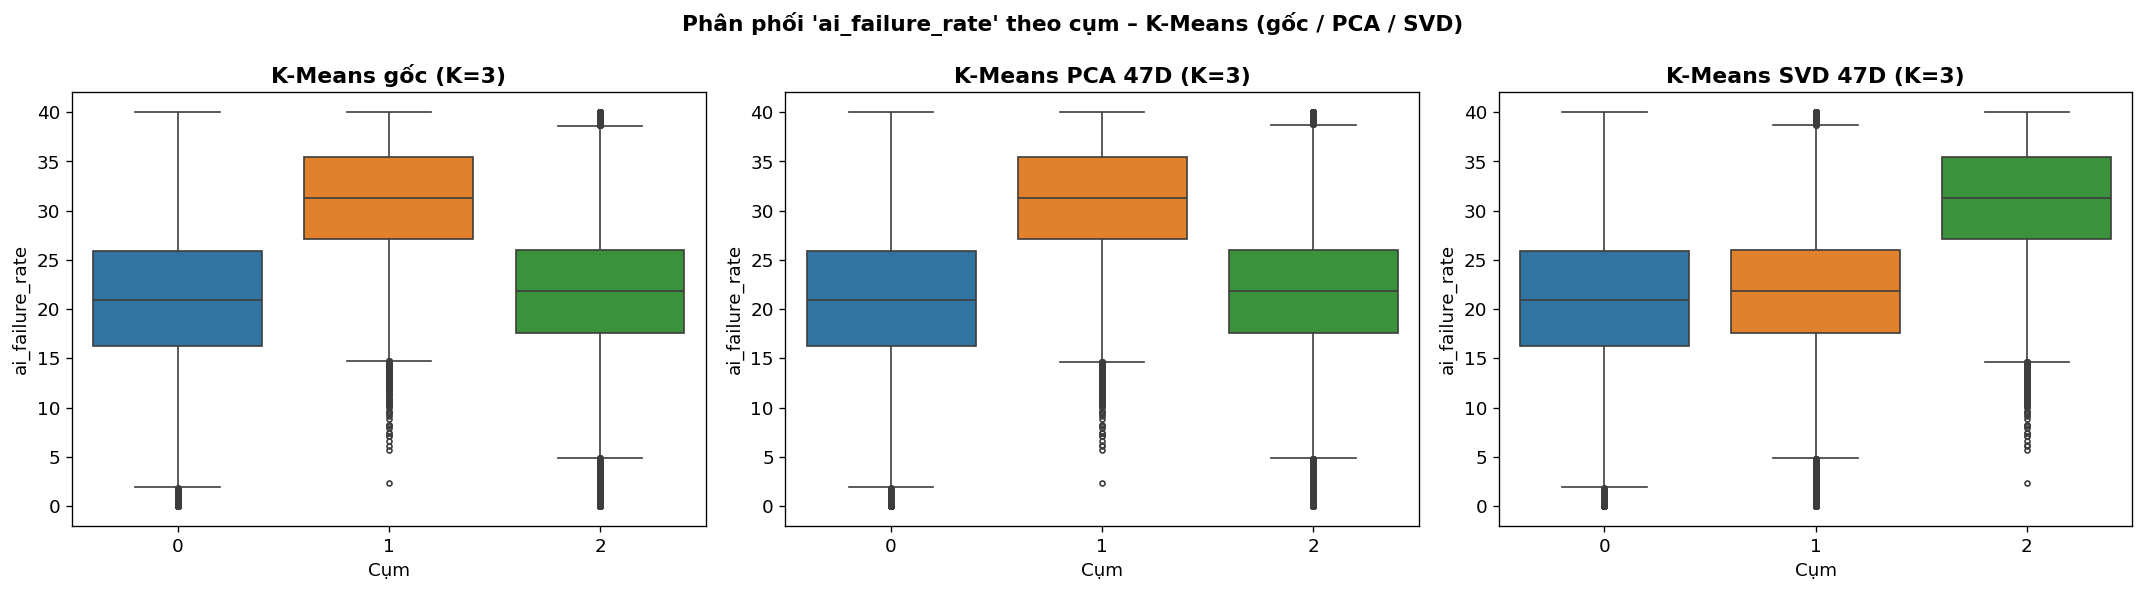


── Thống kê đầu ra theo cụm – K-Means PCA:
Thống kê 'ai_failure_rate' theo cụm – K-Means PCA 47D:


,Số mẫu,Trung bình,Trung vị,Std,Min,Max
cluster,,,,,,
0,21654,21.0758,20.95,7.1053,0.00,40.0
1,66422,31.0250,31.27,5.7453,2.35,40.0
2,61924,21.7852,21.86,6.2961,0.00,40.0



── Thống kê đầu ra theo cụm – K-Means SVD:
Thống kê 'ai_failure_rate' theo cụm – K-Means SVD 47D:


,Số mẫu,Trung bình,Trung vị,Std,Min,Max
cluster,,,,,,
0,21659,21.0767,20.95,7.1054,0.00,40.0
1,61876,21.7810,21.85,6.2951,0.00,40.0
2,66465,31.0228,31.27,5.7455,2.35,40.0


In [32]:
# ── Boxplot đầu ra theo cụm – K-Means (3 không gian) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_output_per_cluster(km_labels,     y, f"K-Means gốc (K={K_OPT})",          axes[0])
plot_output_per_cluster(km_pca_labels, y, f"K-Means PCA {n_pca}D (K={K_OPT})", axes[1])
plot_output_per_cluster(km_svd_labels, y, f"K-Means SVD {n_svd}D (K={K_OPT})", axes[2])
plt.suptitle(f"Phân phối '{TARGET_COL}' theo cụm – K-Means (gốc / PCA / SVD)",
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_DR_KM, '02_output_boxplot_3way.png')
plt.show()

print("\n── Thống kê đầu ra theo cụm – K-Means PCA:")
_ = cluster_output_stats(km_pca_labels, y, f"K-Means PCA {n_pca}D")
print("\n── Thống kê đầu ra theo cụm – K-Means SVD:")
_ = cluster_output_stats(km_svd_labels, y, f"K-Means SVD {n_svd}D")


In [33]:
# ── Đánh giá độ đo K-Means trên không gian giảm chiều ──
km_pca_internal = eval_internal(X_pca_dr, km_pca_labels, f"K-Means PCA {n_pca}D")
km_svd_internal = eval_internal(X_svd_dr, km_svd_labels, f"K-Means SVD {n_svd}D")

km_pca_external = eval_external(km_pca_labels, y_pseudo, f"K-Means PCA {n_pca}D")
km_svd_external = eval_external(km_svd_labels, y_pseudo, f"K-Means SVD {n_svd}D")

print("── Độ đo nội tại – K-Means trên không gian giảm chiều:")
display(pd.DataFrame([km_pca_internal, km_svd_internal]))
print("\n── Độ đo ngoại tại – K-Means trên không gian giảm chiều:")
display(pd.DataFrame([km_pca_external, km_svd_external]))


── Độ đo nội tại – K-Means trên không gian giảm chiều:


,Phương pháp,Số cụm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means PCA 47D,3,0.0730,3.1958,11460.29
1,K-Means SVD 47D,3,0.0732,3.1943,11470.58



── Độ đo ngoại tại – K-Means trên không gian giảm chiều:


,Phương pháp,Rand Index,ARI,Mutual Information,AMI,NMI
0,K-Means PCA 47D,0.6291,0.198,0.1932,0.1836,0.1836
1,K-Means SVD 47D,0.6291,0.198,0.1932,0.1837,0.1837


### 8.3 GMM trên dữ liệu giảm chiều

Dùng cùng số cụm `N_OPT` đã chọn ở mục 4.


In [34]:
# ── GMM trên PCA ──
gmm_pca = GaussianMixture(n_components=N_OPT, covariance_type='full',
                           random_state=42, n_init=5)
gmm_pca_labels = gmm_pca.fit_predict(X_pca_dr)
gmm_pca_proba  = gmm_pca.predict_proba(X_pca_dr)

# ── GMM trên SVD ──
gmm_svd = GaussianMixture(n_components=N_OPT, covariance_type='full',
                           random_state=42, n_init=5)
gmm_svd_labels = gmm_svd.fit_predict(X_svd_dr)
gmm_svd_proba  = gmm_svd.predict_proba(X_svd_dr)

print(f"GMM (K={N_OPT}) trên PCA – phân bố cụm:")
print(pd.Series(gmm_pca_labels).value_counts().sort_index().rename("Số mẫu"))
print(f"\nGMM (K={N_OPT}) trên SVD – phân bố cụm:")
print(pd.Series(gmm_svd_labels).value_counts().sort_index().rename("Số mẫu"))

# Độ chắc chắn
for lbl, proba, name in [
    (gmm_pca_labels, gmm_pca_proba, 'PCA'),
    (gmm_svd_labels, gmm_svd_proba, 'SVD')
]:
    max_p = proba.max(axis=1)
    print(f"\nĐộ chắc chắn max probability – GMM {name}:")
    print(pd.Series(max_p).describe().round(4))


GMM (K=3) trên PCA – phân bố cụm:
0    64650
1    45137
2    40213
Name: Số mẫu, dtype: int64

GMM (K=3) trên SVD – phân bố cụm:
0    40213
1    45090
2    64697
Name: Số mẫu, dtype: int64

Độ chắc chắn max probability – GMM PCA:
count    150000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
dtype: float64

Độ chắc chắn max probability – GMM SVD:
count    150000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
dtype: float64


  Saved → figure\03_clustering\dim_reduced\gmm\01_gmm_3way_comparison.png


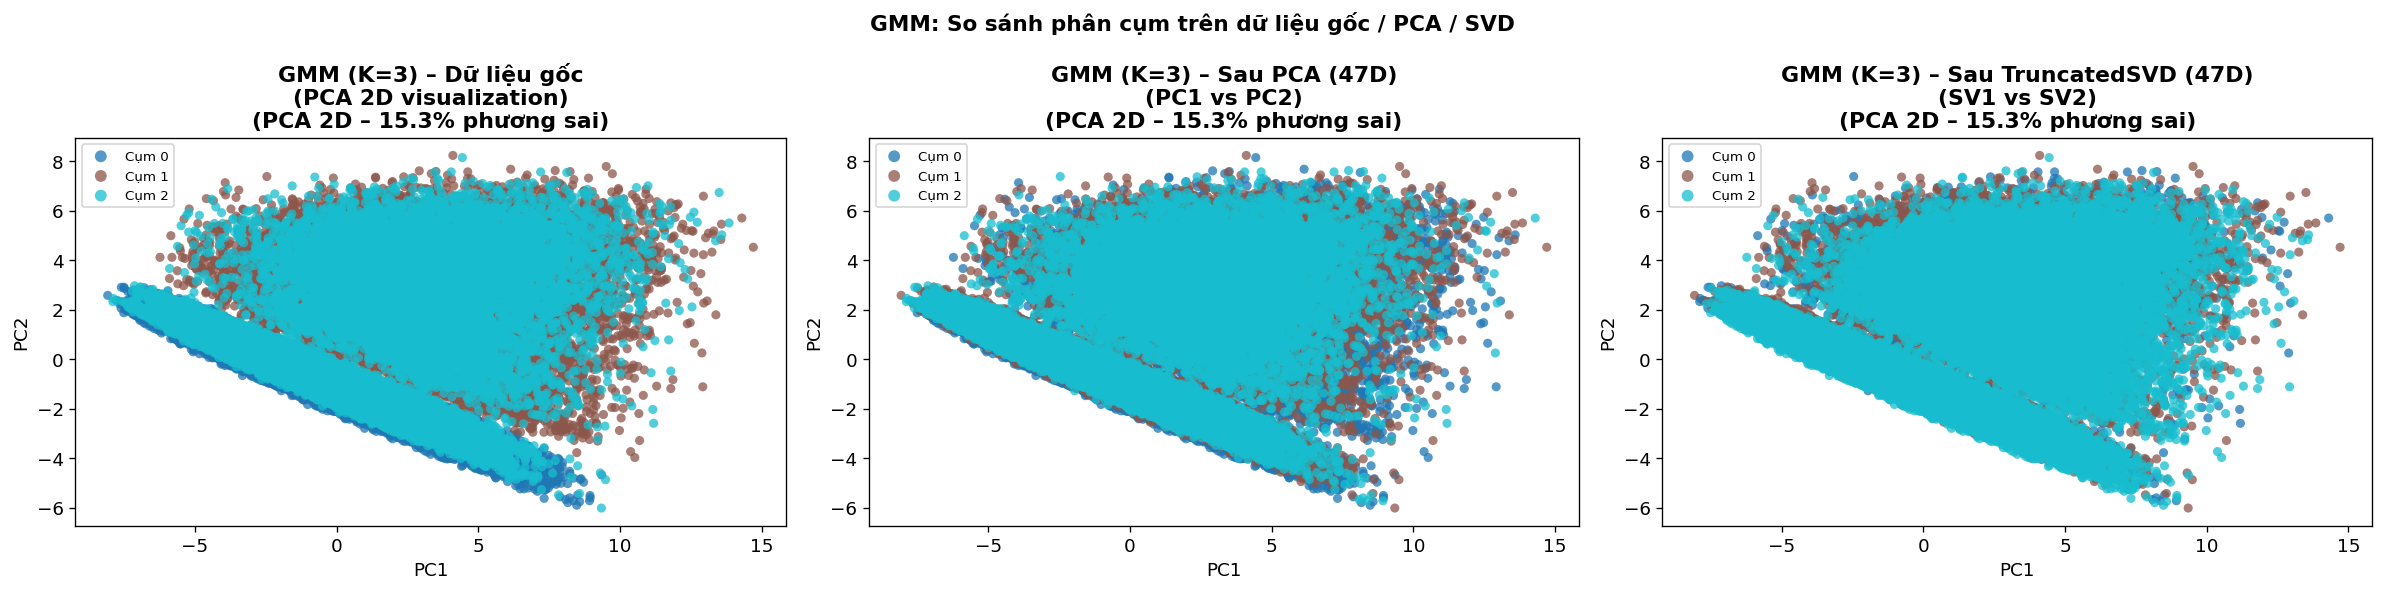

In [35]:
# ── Trực quan hóa GMM trên dữ liệu giảm chiều ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_clusters_pca(X_pca2, gmm_labels,
                  f"GMM (K={N_OPT}) – Dữ liệu gốc\n(PCA 2D visualization)",
                  axes[0], var2)
plot_clusters_pca(X_pca_dr[:, :2], gmm_pca_labels,
                  f"GMM (K={N_OPT}) – Sau PCA ({n_pca}D)\n(PC1 vs PC2)",
                  axes[1], var_pca_2d)
plot_clusters_pca(X_svd_dr[:, :2], gmm_svd_labels,
                  f"GMM (K={N_OPT}) – Sau TruncatedSVD ({n_svd}D)\n(SV1 vs SV2)",
                  axes[2], var_svd_2d)

plt.suptitle('GMM: So sánh phân cụm trên dữ liệu gốc / PCA / SVD',
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_DR_GMM, '01_gmm_3way_comparison.png')
plt.show()


  Saved → figure\03_clustering\dim_reduced\gmm\02_soft_assignment_pca_vs_svd.png


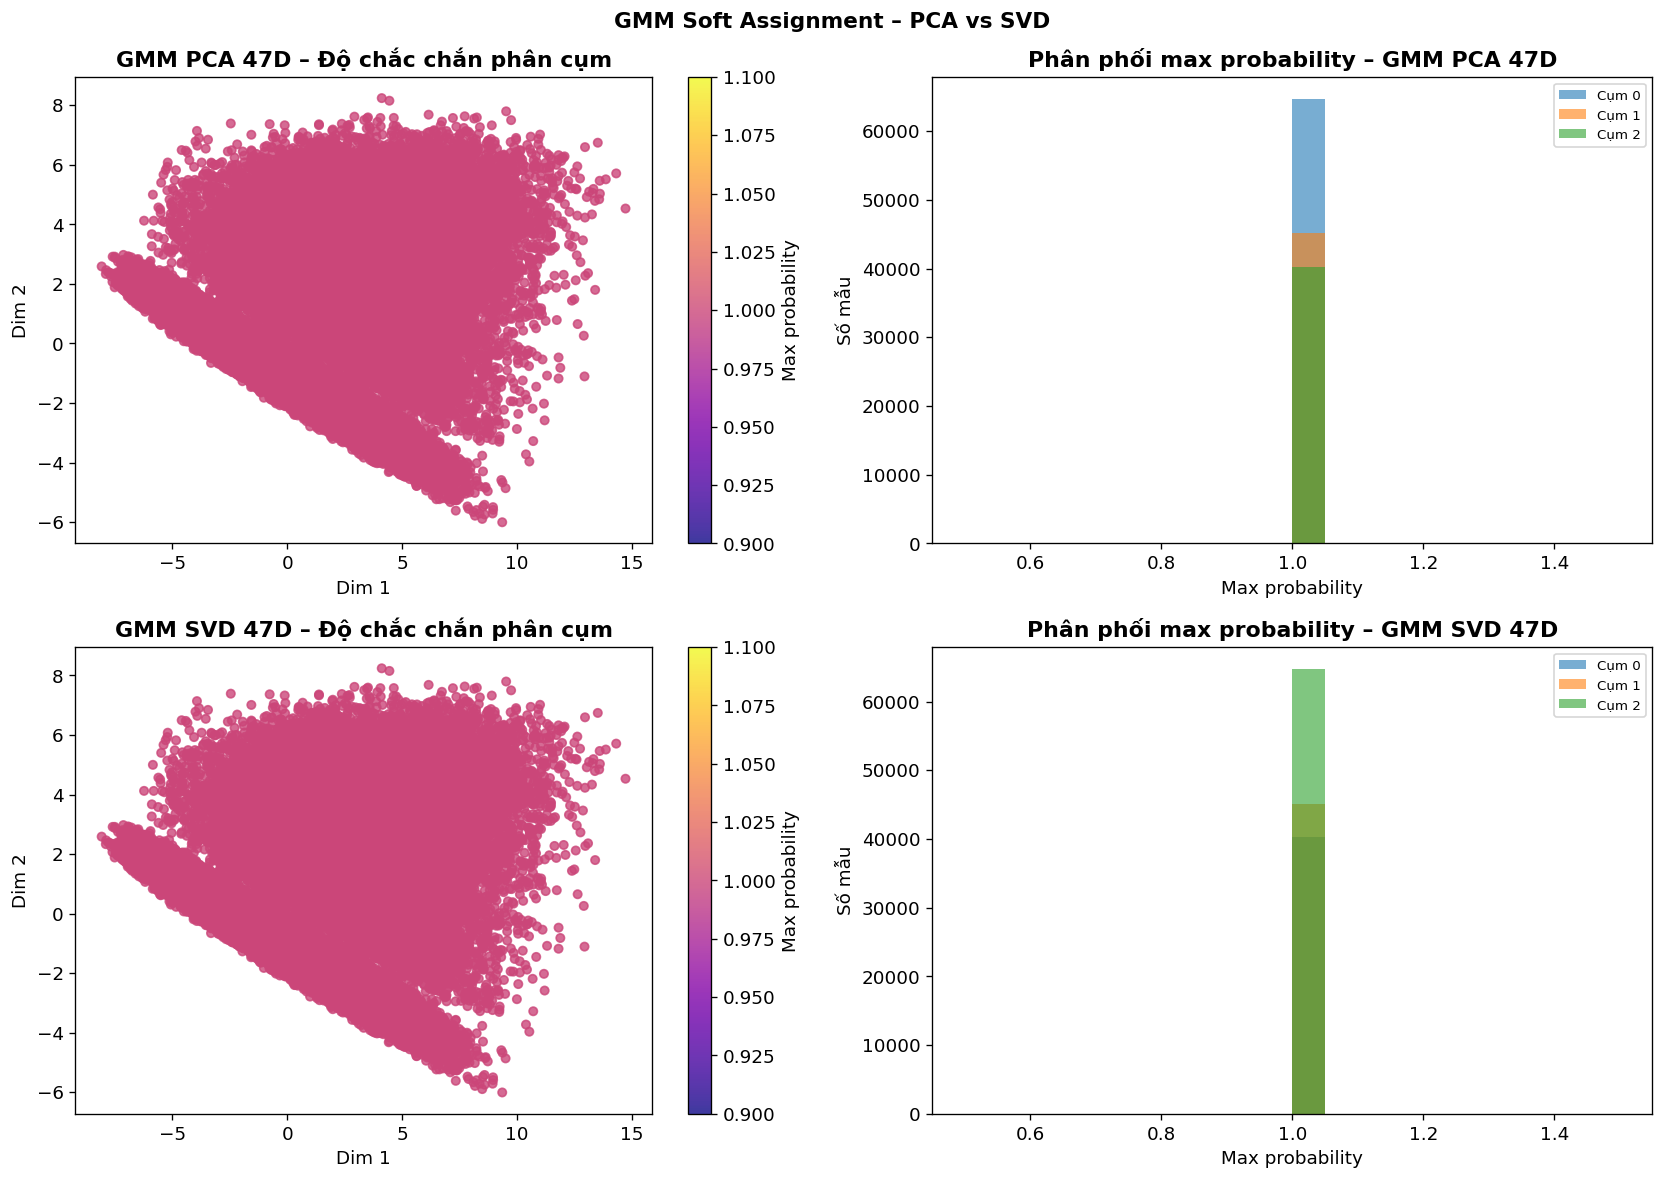

In [36]:
# ── Soft assignment confidence – GMM trên PCA vs SVD ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (proba, lbl, name) in enumerate([
    (gmm_pca_proba, gmm_pca_labels, f'PCA {n_pca}D'),
    (gmm_svd_proba, gmm_svd_labels, f'SVD {n_svd}D'),
]):
    max_p = proba.max(axis=1)
    X_2d  = X_pca_dr[:, :2] if name.startswith('PCA') else X_svd_dr[:, :2]

    sc = axes[row, 0].scatter(X_2d[:, 0], X_2d[:, 1],
                              c=max_p, cmap='plasma', s=25, alpha=0.8)
    plt.colorbar(sc, ax=axes[row, 0], label='Max probability')
    axes[row, 0].set_title(f'GMM {name} – Độ chắc chắn phân cụm', fontweight='bold')
    axes[row, 0].set_xlabel('Dim 1'); axes[row, 0].set_ylabel('Dim 2')

    for k in sorted(set(lbl)):
        axes[row, 1].hist(max_p[lbl == k], bins=20, alpha=0.6, label=f'Cụm {k}')
    axes[row, 1].set_title(f'Phân phối max probability – GMM {name}', fontweight='bold')
    axes[row, 1].set_xlabel('Max probability'); axes[row, 1].set_ylabel('Số mẫu')
    axes[row, 1].legend(fontsize=8)

plt.suptitle('GMM Soft Assignment – PCA vs SVD', fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_DR_GMM, '02_soft_assignment_pca_vs_svd.png')
plt.show()


In [37]:
# ── Đánh giá độ đo GMM trên không gian giảm chiều ──
gmm_pca_internal = eval_internal(X_pca_dr, gmm_pca_labels, f"GMM PCA {n_pca}D")
gmm_svd_internal = eval_internal(X_svd_dr, gmm_svd_labels, f"GMM SVD {n_svd}D")

gmm_pca_external = eval_external(gmm_pca_labels, y_pseudo, f"GMM PCA {n_pca}D")
gmm_svd_external = eval_external(gmm_svd_labels, y_pseudo, f"GMM SVD {n_svd}D")

print("── Đánh giá nội tại – GMM trên không gian giảm chiều:")
display(pd.DataFrame([gmm_pca_internal, gmm_svd_internal]))
print("\n── Đánh giá ngoại tại – GMM trên không gian giảm chiều:")
display(pd.DataFrame([gmm_pca_external, gmm_svd_external]))


── Đánh giá nội tại – GMM trên không gian giảm chiều:


,Phương pháp,Số cụm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,GMM PCA 47D,3,0.0252,6.1861,2694.93
1,GMM SVD 47D,3,0.0201,6.2432,2678.83



── Đánh giá ngoại tại – GMM trên không gian giảm chiều:


,Phương pháp,Rand Index,ARI,Mutual Information,AMI,NMI
0,GMM PCA 47D,0.5513,0.0016,0.0015,0.0014,0.0014
1,GMM SVD 47D,0.5515,0.0020,0.0018,0.0017,0.0017


### 8.4 So sánh tổng hợp: Dữ liệu gốc vs PCA vs SVD

Bảng tổng hợp tất cả kịch bản phân cụm để so sánh toàn diện.


In [38]:
# ── Bảng tổng hợp độ đo nội tại ──
all_internal = pd.DataFrame([
    km_internal,
    km_pca_internal,
    km_svd_internal,
    gmm_internal,
    gmm_pca_internal,
    gmm_svd_internal,
]).set_index('Phương pháp')

print("=" * 70)
print("BẢNG ĐỘ ĐO NỘI TẠI – TẤT CẢ KỊCH BẢN")
print("  Silhouette        : ↑ tốt hơn (max = 1)")
print("  Davies-Bouldin    : ↓ tốt hơn (min = 0)")
print("  Calinski-Harabasz : ↑ tốt hơn")
print("=" * 70)
display(all_internal)


BẢNG ĐỘ ĐO NỘI TẠI – TẤT CẢ KỊCH BẢN
  Silhouette        : ↑ tốt hơn (max = 1)
  Davies-Bouldin    : ↓ tốt hơn (min = 0)
  Calinski-Harabasz : ↑ tốt hơn


,Số cụm,Silhouette,Davies-Bouldin,Calinski-Harabasz
Phương pháp,,,,
K-Means (K=3),3,0.0589,3.6025,9039.82
K-Means PCA 47D,3,0.0730,3.1958,11460.29
K-Means SVD 47D,3,0.0732,3.1943,11470.58
GMM (K=3),3,0.0386,4.3287,5397.80
GMM PCA 47D,3,0.0252,6.1861,2694.93
GMM SVD 47D,3,0.0201,6.2432,2678.83


In [39]:
# ── Bảng tổng hợp độ đo ngoại tại ──
all_external = pd.DataFrame([
    km_external,
    km_pca_external,
    km_svd_external,
    gmm_external,
    gmm_pca_external,
    gmm_svd_external,
]).set_index('Phương pháp')

print("=" * 70)
print("BẢNG ĐỘ ĐO NGOẠI TẠI – TẤT CẢ KỊCH BẢN")
print("  (pseudo ground truth = quantile-bin 3 nhóm của ai_failure_rate)")
print("=" * 70)
display(all_external)


BẢNG ĐỘ ĐO NGOẠI TẠI – TẤT CẢ KỊCH BẢN
  (pseudo ground truth = quantile-bin 3 nhóm của ai_failure_rate)


,Rand Index,ARI,Mutual Information,AMI,NMI
Phương pháp,,,,,
K-Means (K=3),0.6301,0.2003,0.1955,0.1858,0.1858
K-Means PCA 47D,0.6291,0.1980,0.1932,0.1836,0.1836
K-Means SVD 47D,0.6291,0.1980,0.1932,0.1837,0.1837
GMM (K=3),0.5247,0.0093,0.0141,0.0138,0.0139
GMM PCA 47D,0.5513,0.0016,0.0015,0.0014,0.0014
GMM SVD 47D,0.5515,0.0020,0.0018,0.0017,0.0017


  Saved → figure\03_clustering\dim_reduced\comparison\01_all_metrics_heatmap.png


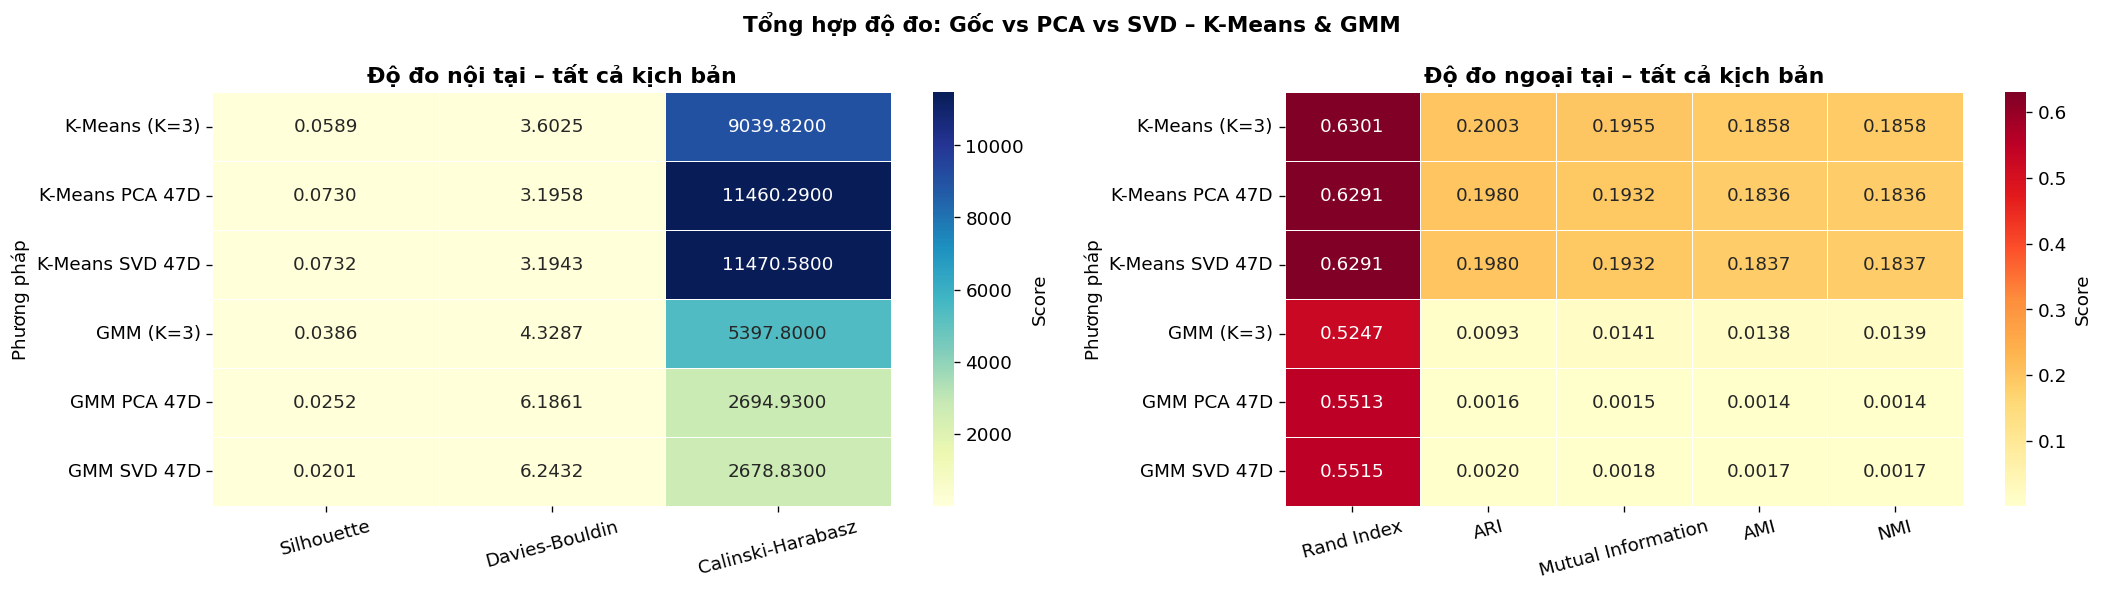

In [40]:
# ── Heatmap tổng hợp tất cả kịch bản ──
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Nội tại
internal_plot = all_internal[['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']].astype(float)
sns.heatmap(internal_plot, annot=True, fmt='.4f', cmap='YlGnBu',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Score'})
axes[0].set_title('Độ đo nội tại – tất cả kịch bản', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Ngoại tại
sns.heatmap(all_external.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Score'})
axes[1].set_title('Độ đo ngoại tại – tất cả kịch bản', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Tổng hợp độ đo: Gốc vs PCA vs SVD – K-Means & GMM',
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig(fig, FIG_DR_CMP, '01_all_metrics_heatmap.png')
plt.show()


In [41]:
# ── So sánh chéo chéo: nhãn gốc vs giảm chiều ──
cross_results = []
for lbl_dr, name_dr in [
    (km_pca_labels,  f"K-Means PCA {n_pca}D"),
    (km_svd_labels,  f"K-Means SVD {n_svd}D"),
    (gmm_pca_labels, f"GMM PCA {n_pca}D"),
    (gmm_svd_labels, f"GMM SVD {n_svd}D"),
]:
    ref_lbl  = km_labels  if name_dr.startswith('K-Means') else gmm_labels
    ref_name = f"K-Means gốc (K={K_OPT})" if name_dr.startswith('K-Means') else f"GMM gốc (K={N_OPT})"
    cross_results.append(eval_crossmethod(lbl_dr, ref_lbl, name_dr, ref_name))

cross_df_all = pd.DataFrame(cross_results).set_index('Cặp so sánh')
print("SO SÁNH CHÉO: nhãn phân cụm dữ liệu giảm chiều vs dữ liệu gốc")
print("  ARI/NMI gần 1 → giảm chiều bảo toàn cấu trúc phân cụm tốt")
display(cross_df_all)

savefig(plt.figure(figsize=(1, 1)), FIG_DR_CMP, 'placeholder.png')  # dummy
plt.close()


SO SÁNH CHÉO: nhãn phân cụm dữ liệu giảm chiều vs dữ liệu gốc
  ARI/NMI gần 1 → giảm chiều bảo toàn cấu trúc phân cụm tốt


,Rand Index,ARI,Mutual Information,AMI,NMI
Cặp so sánh,,,,,
K-Means PCA 47D vs K-Means gốc (K=3),0.9903,0.9796,0.9679,0.9629,0.9629
K-Means SVD 47D vs K-Means gốc (K=3),0.9904,0.9797,0.9680,0.9630,0.9630
GMM PCA 47D vs GMM gốc (K=3),0.5227,0.0087,0.0041,0.0040,0.0040
GMM SVD 47D vs GMM gốc (K=3),0.5223,0.0081,0.0040,0.0039,0.0039


  Saved → figure\03_clustering\dim_reduced\comparison\placeholder.png
